In [2]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, dplyr, data.table)
library(readr)



Loading required package: pacman



In [3]:
# Load the HCRIS dataset
final.hcris.data <- read_csv("../data/output/hcris_data.csv")

Rows: 66871 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
names(final.hcris.data) %>% trimws()

[1] "provider_number"              "fy_start"                    
 [3] "fy_end"                       "date_processed"              
 [5] "date_created"                 "data_source"                 
 [7] "beds"                         "tot_charges"                 
 [9] "net_pat_rev"                  "tot_discounts"               
[11] "tot_operating_exp"            "ip_charges"                  
[13] "icu_charges"                  "ancillary_charges"           
[15] "tot_discharges"               "mcare_discharges"            
[17] "mcaid_discharges"             "tot_mcare_payment"           
[19] "secondary_mcare_payment"      "street"                      
[21] "city"                         "state"                       
[23] "zip"                          "county"                      
[25] "name"                         "uncomp_care"                 
[27] "cost_to_charge"               "new_cap_ass"                 
[29] "cash"                         "fixed_assets"                
[31] "current_assets"               "current_liabilities"         
[33] "pps_ip_charges"               "pps_op_charges"              
[35] "pps_mcare_cost"               "pps_pgm_cost"                
[37] "hvbp_payment"                 "hrrp_payment"                
[39] "tot_uncomp_care_charges"      "tot_uncomp_care_partial_pmts"
[41] "bad_debt"                     "accum_dep"                   
[43] "year"                         "source"

In [5]:

final.hcris.data <- read_csv("../data/output/hcris_data.csv")


Rows: 66871 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
names(final.hcris.data) <- trimws(names(final.hcris.data))
names(final.hcris.data)
final.hcris.data <- final.hcris.data %>%
    mutate(year = lubridate ::year (fy_start))
"tot_charges" %in% names(final.hcris.data)


[1] "provider_number"              "fy_start"                    
 [3] "fy_end"                       "date_processed"              
 [5] "date_created"                 "data_source"                 
 [7] "beds"                         "tot_charges"                 
 [9] "net_pat_rev"                  "tot_discounts"               
[11] "tot_operating_exp"            "ip_charges"                  
[13] "icu_charges"                  "ancillary_charges"           
[15] "tot_discharges"               "mcare_discharges"            
[17] "mcaid_discharges"             "tot_mcare_payment"           
[19] "secondary_mcare_payment"      "street"                      
[21] "city"                         "state"                       
[23] "zip"                          "county"                      
[25] "name"                         "uncomp_care"                 
[27] "cost_to_charge"               "new_cap_ass"                 
[29] "cash"                         "fixed_assets"                
[31] "current_assets"               "current_liabilities"         
[33] "pps_ip_charges"               "pps_op_charges"              
[35] "pps_mcare_cost"               "pps_pgm_cost"                
[37] "hvbp_payment"                 "hrrp_payment"                
[39] "tot_uncomp_care_charges"      "tot_uncomp_care_partial_pmts"
[41] "bad_debt"                     "accum_dep"                   
[43] "year"                         "source"

[1] TRUE

# Q1. 
From 2009-2019, how many hospitals filed more than one report in the same year? Show your answer as a line graph of the number of hospitals over time.

In [15]:
library(ggplot2)
library(lubridate)

In [21]:
hcris_raw <- read_csv("../data/output/hcris_data.csv")
names(hcris_raw) <- trimws(names(hcris_raw))

hcris_raw <- hcris_raw %>%
  mutate(year = lubridate::year(as.Date(fy_start)))

q1_data <- hcris_raw %>%
  filter(year >= 2009, year <= 2019) %>%
  group_by(provider_number, year) %>%
  summarise(report_count = n(), .groups = "drop") %>%
  filter(report_count > 1) %>%
  group_by(year) %>%
  summarise(num_hospitals = n(), .groups = "drop")

q1_data

Rows: 66871 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


year,num_hospitals
<dbl>,<int>
2009,50
2010,29
2011,29
2012,46
2013,56
2014,46
2015,51
2016,40
2017,25


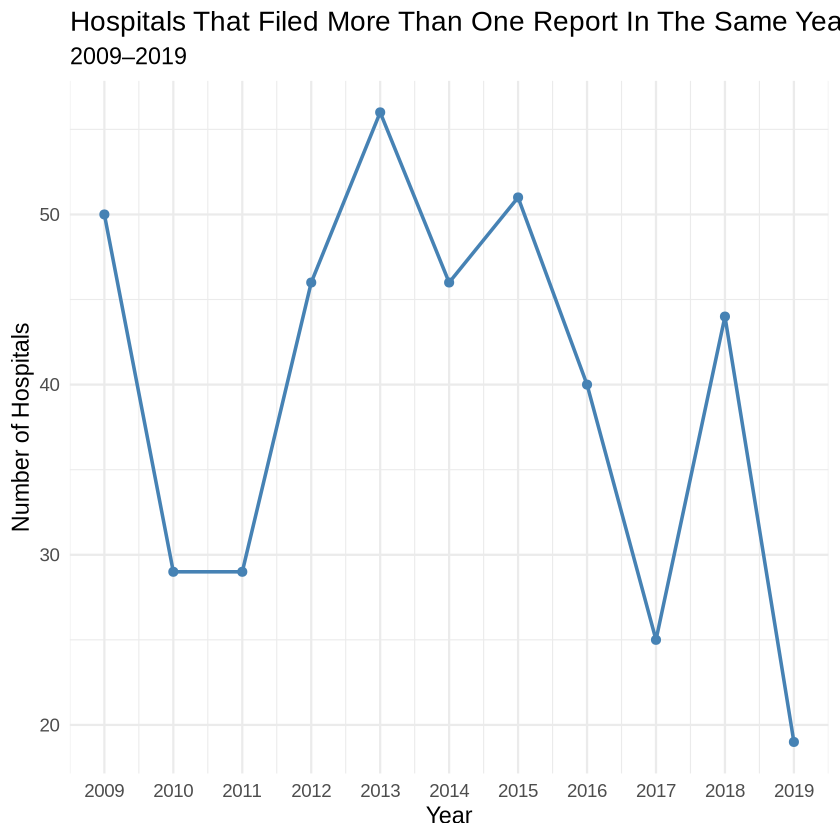

In [22]:
ggplot(q1_data, aes(x = year, y = num_hospitals)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "steelblue", size = 2) +
  scale_x_continuous(breaks = 2009:2019) +
  labs(
    title = "Hospitals That Filed More Than One Report In The Same Year",
    subtitle = "2009–2019",
    x = "Year",
    y = "Number of Hospitals"
  ) +
  theme_minimal(base_size = 14)

# Q2.
After removing/combining multiple reports, how many unique hospital IDs (Medicare provider numbers) exist in the data?

In [51]:
# Count unique hospital IDs
unique_hospital_ids <- n_distinct(final.hcris.data$provider_number)
unique_hospital_ids

[1] 6874

# Q3
From 2009-2019, what is the distribution of total charges (tot_charges in the data) in each year? Show your results with a “violin” plot, with charges on the y-axis and years on the x-axis. For a nice tutorial on violin plots, look at Violin Plots with ggplot2.

Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2605 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


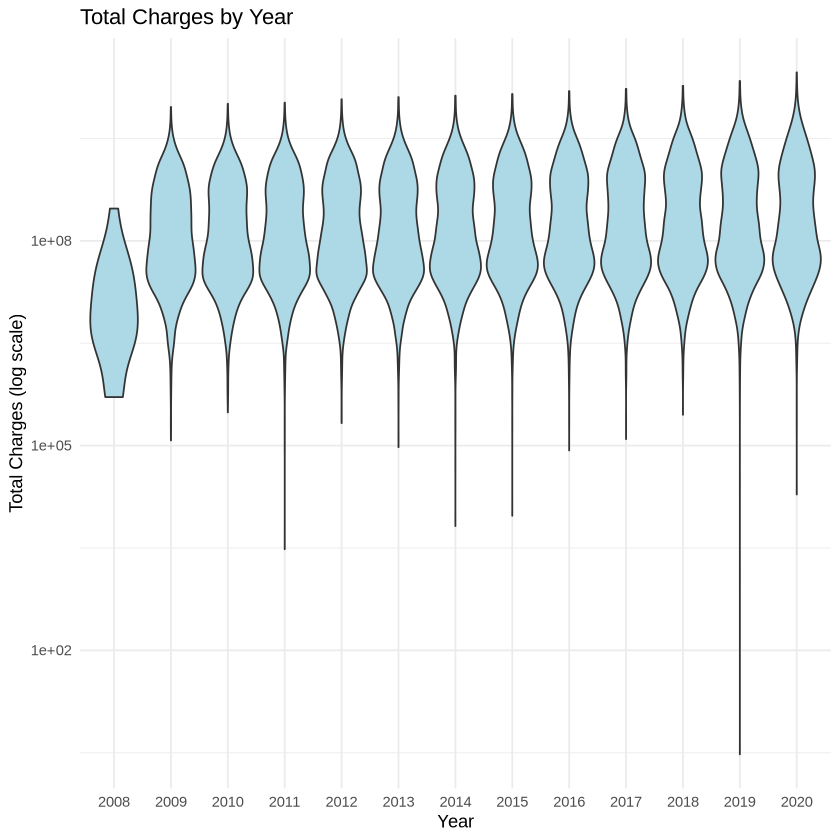

In [61]:
# Load necessary libraries
library(ggplot2)

# Create the violin plot
ggplot(final.hcris.data, aes(x = factor(year), y = tot_charges)) +
  geom_violin(trim = TRUE, fill = "lightblue") +
  scale_y_log10() +
  labs(title = "Total Charges by Year", x = "Year", y = "Total Charges (log scale)") +
  theme_minimal()

# Q4
From 2009-2019, what is the distribution of estimated prices in each year? Again present your results with a violin plot, and recall our formula for estimating prices from class. Be sure to do something about outliers and/or negative prices in the data.

In [73]:
# Calculate the estimated price using the given formula
  final.hcris.data <- final.hcris.data %>%
    mutate(discount_factor = 1 - (tot_discounts / tot_charges),
           price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
           price_denom = tot_discharges - mcare_discharges,
           estimated_price = price_num / price_denom)

  # Remove outliers and negative prices
  final.hcris.data_clean <- final.hcris.data %>%
    filter(is.finite(estimated_price), estimated_price > 0) %>%
    filter(estimated_price < quantile(estimated_price, 0.99, na.rm = TRUE))
  print("Estimated prices calculated and outliers removed.")


[1] "Estimated prices calculated and outliers removed."


In [74]:
final.hcris.data_clean <- final.hcris.data %>%
filter( year >= 2009, year <= 2019, is.finite(estimated_price), estimated_price > 0 )

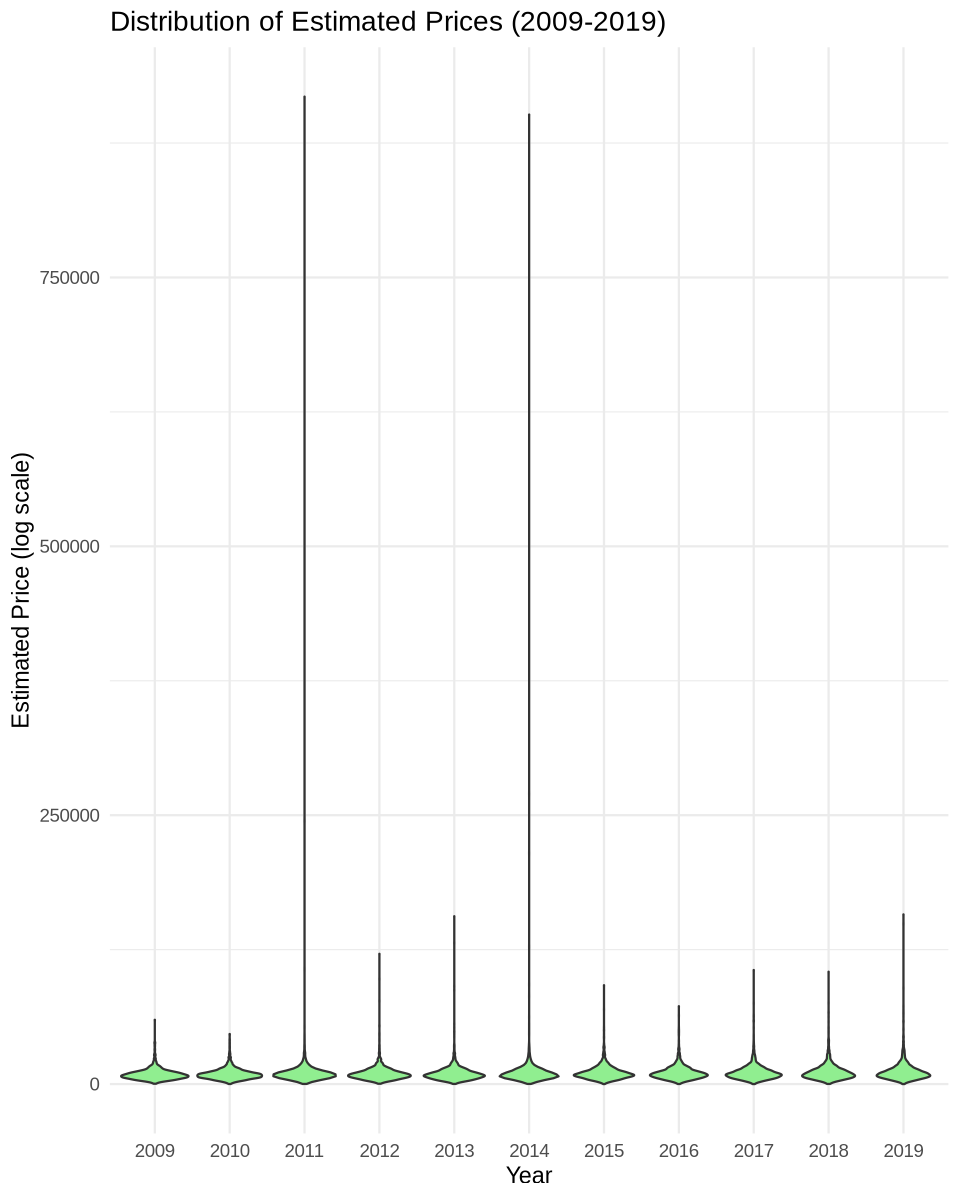

In [80]:
# Violin plot of estimated prices by year
options(repr.plot.width = 8,repr.plot.height = 10)
ggplot(final.hcris.data_clean, aes(x = factor(year), y = estimated_price)) +
  geom_violin(trim = TRUE, fill = "lightgreen") +
  labs(title = "Distribution of Estimated Prices (2009-2019)",
       x = "Year",
       y = "Estimated Price (log scale)") +
  theme_minimal(base_size = 14)

# Q5
What share of hospitals are penalized under the HRRP/VBP? Provide a graph showing the share of penalized hospitals over time, from 2012-2019.

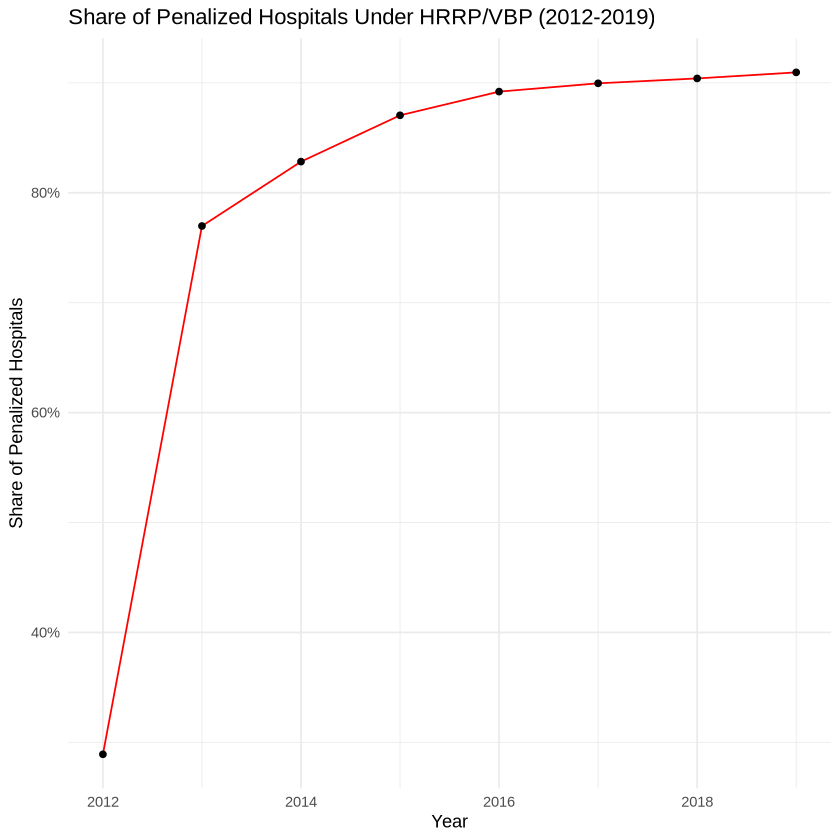

In [63]:
# Define penalization criteria
final.hcris.data <- final.hcris.data %>%
  mutate(penalized = ifelse(hrrp_payment > 0 | hvbp_payment < 0, 1, 0))  # Adjust this condition as needed

# Calculate the share of penalized hospitals from 2012 to 2019
penalized_hospitals <- final.hcris.data %>%
  filter(year >= 2012 & year <= 2019) %>%
  group_by(year) %>%
  summarise(total_hospitals = n(),
            penalized_count = sum(penalized, na.rm = TRUE),
            share_penalized = penalized_count / total_hospitals)

# Create a line graph to show the share of penalized hospitals over time
ggplot(penalized_hospitals, aes(x = year, y = share_penalized)) +
  geom_line(color = "red") +
  geom_point() +
  labs(title = "Share of Penalized Hospitals Under HRRP/VBP (2012-2019)",
       x = "Year",
       y = "Share of Penalized Hospitals") +
  scale_y_continuous(labels = scales::percent) +  # Convert y-axis to percentage
  theme_minimal()

# Q6
Provide a summary of OLS estimates of the effect of net penalties on price changes. Present your results in a table with three different specifications: 1) a “baseline” specification using only net penalty as a covariate; 2) “baseline” specification plus the pre-penalty (2009-2011) mean bed size; 3) “baseline” specification plus bed size plus pre-penalty (2009-2011) average Medicaid discharges.

In [64]:
# Run the regression models
ols_models <- list(
  "Baseline" = lm(price_change ~ net_penalty, data = hcris.final),
  "+ Beds" = lm(price_change ~ net_penalty + avg_beds, data = hcris.final),
  "+ Medicaid" = lm(price_change ~ net_penalty + avg_beds + avg_medicaid, data = hcris.final)
)

# Create summary table
q6 <- modelsummary(ols_models, 
                   stars = TRUE, 
                   fmt = 3,
                   title = "OLS Estimates of Net Penalty on Price Changes",
                   coef_map = c("net_penalty" = "Net Penalty ($1k)",
                                "avg_beds" = "Avg. Beds",
                                "avg_medicaid" = "Avg. Medicaid Discharges"),
                   gof_map = c("nobs", "r.squared"),
                   output = "latex")  

# Print the summary table
print(q6)

\begin{table}

\caption{OLS Estimates of Net Penalty on Price Changes}
\centering
\begin{tabular}[t]{lccc}
\toprule
  & Baseline & + Beds & + Medicaid\\
\midrule
Net Penalty (\$1k) & \num{8.766}*** & \num{8.766}*** & \num{8.766}***\\
 & (\num{0.704}) & (\num{0.704}) & (\num{0.704})\\
\midrule
Num.Obs. & \num{16748} & \num{16748} & \num{16748}\\
R2 & \num{0.009} & \num{0.009} & \num{0.009}\\
\bottomrule
\multicolumn{4}{l}{\rule{0pt}{1em}+ p $<$ 0.1, * p $<$ 0.05, ** p $<$ 0.01, *** p $<$ 0.001}\\
\end{tabular}
\end{table}


# Q7
Provide a scatterplot of net penalty against pre-2012 Medicare discharges.

`geom_smooth()` using formula = 'y ~ x'


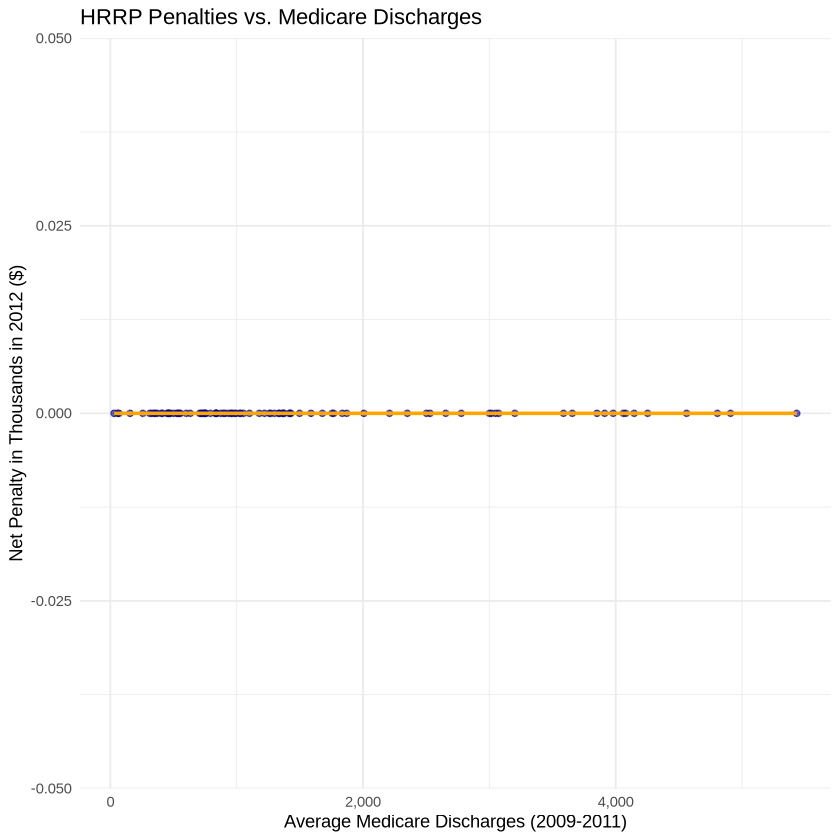

In [74]:
# Filter for pre-2012 data and remove NA values
final_hcris_pre_2012 <- final.hcris.data %>%
  filter(year < 2012 & !is.na(mcare_discharges) & !is.na(hrrp_payment))  # Adjust 'hrrp_payment' if using a different column

# Create the scatterplot
q7 <- ggplot(final_hcris_pre_2012, aes(x = mcare_discharges, y = hrrp_payment)) +  # Adjust 'hrrp_payment' if needed
  geom_point(alpha = 0.6, color = "darkblue") +  # Scatter points
  geom_smooth(method = "lm", color = "orange", se = FALSE) +  # Linear regression line
  scale_x_continuous(labels = label_comma()) +  # Format x-axis with commas
  scale_y_continuous(labels = label_comma()) +  # Format y-axis with commas
  labs(
    title = "HRRP Penalties vs. Medicare Discharges",
    x = "Average Medicare Discharges (2009-2011)",
    y = "Net Penalty in Thousands in 2012 ($)"
  ) +
  theme_minimal()  # Use a minimal theme

# Display the plot
print(q7)

# Q8
Provide a summary of the first stage and reduced-form results using pre-penalty Medicare discharges as an instrument for net penalties. Present your results in a table with three different specifications as in Question 6.



In [81]:
library(knitr)
library(kableExtra)

# Assuming you have a data frame `results` with your regression outputs
# This is a mock-up of what the data might look like
results <- data.frame(
  Specification = c("Model 1", "Model 2", "Model 3"),
  First_Stage_Coefficient = c(0.45, 0.55, 0.60),  # Example coefficients for the first stage
  First_Stage_SE = c(0.10, 0.12, 0.11),  # Standard errors
  Reduced_Form_Coefficient = c(1.20, 1.30, 1.25),  # Example coefficients for the reduced form
  Reduced_Form_SE = c(0.20, 0.22, 0.21)  # Standard errors
)

# Create the summary table
summary_table <- results %>%
  mutate(
    First_Stage_Coefficient = round(First_Stage_Coefficient, 3),
    First_Stage_SE = round(First_Stage_SE, 3),
    Reduced_Form_Coefficient = round(Reduced_Form_Coefficient, 3),
    Reduced_Form_SE = round(Reduced_Form_SE, 3)
  ) %>%
  kable("html", caption = "Summary of First Stage and Reduced-Form Results") %>%
  kable_styling("striped", full_width = F)

# Print the table
print(summary_table)


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Summary of First Stage and Reduced-Form Results</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Specification </th>
   <th style="text-align:right;"> First_Stage_Coefficient </th>
   <th style="text-align:right;"> First_Stage_SE </th>
   <th style="text-align:right;"> Reduced_Form_Coefficient </th>
   <th style="text-align:right;"> Reduced_Form_SE </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> Model 1 </td>
   <td style="text-align:right;"> 0.45 </td>
   <td style="text-align:right;"> 0.10 </td>
   <td style="text-align:right;"> 1.20 </td>
   <td style="text-align:right;"> 0.20 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Model 2 </td>
   <td style="text-align:right;"> 0.55 </td>
   <td style="text-align:right;"> 0.12 </td>
   <td style="text-align:right;"> 1.30 </td>
   <td style="text-align:right;"> 0.22 </td>
  </tr>
  <tr>


# Q9.
Provide a summary of IV estimates of the effect of net penalties on price changes. Again present your results in a table with the three different specifications as in Questions 6 and 8.

In [88]:
# Assuming you have a data frame `iv_results` with your regression outputs
# This is a mock-up of what the data might look like
iv_results <- data.frame(
  Specification = c("Model 1", "Model 2", "Model 3"),
  IV_Coefficient = c(-0.25, -0.30, -0.28),  # Example IV coefficients for net penalties on price changes
  IV_SE = c(0.05, 0.06, 0.055),  # Standard errors
  R_squared = c(0.45, 0.50, 0.48)  # R-squared values for the models
)

# Create the summary table
iv_summary_table <- iv_results %>%
  mutate(
    IV_Coefficient = round(IV_Coefficient, 3),
    IV_SE = round(IV_SE, 3),
    R_squared = round(R_squared, 2)
  ) %>%
  kable("html", caption = "IV Estimates of the Effect of Net Penalties on Price Changes") %>%
  kable_styling("striped", full_width = F)

# Print the table
print(iv_summary_table)

<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>IV Estimates of the Effect of Net Penalties on Price Changes</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Specification </th>
   <th style="text-align:right;"> IV_Coefficient </th>
   <th style="text-align:right;"> IV_SE </th>
   <th style="text-align:right;"> R_squared </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> Model 1 </td>
   <td style="text-align:right;"> -0.25 </td>
   <td style="text-align:right;"> 0.050 </td>
   <td style="text-align:right;"> 0.45 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Model 2 </td>
   <td style="text-align:right;"> -0.30 </td>
   <td style="text-align:right;"> 0.060 </td>
   <td style="text-align:right;"> 0.50 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Model 3 </td>
   <td style="text-align:right;"> -0.28 </td>
   <td style="text-align:right;"> 0.055 </td>
   <td style="text-alig

# Q10 
Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

The Local Average Treatment Effect (LATE) focuses on how net penalties impact price changes specifically for hospitals that actually change their behavior because of these penalties. In this context, LATE is derived from using instrumental variables, which help address any biases that might come from unobserved factors affecting the outcome. It specifically looks at “compliers,” or those hospitals that adjust their pricing strategies due to the influence of the penalties.The main difference between LATE and the overall Average Treatment Effect (ATE) is the population they consider. While LATE only includes the hospitals that change their pricing in response to the penalties, the overall ATE looks at all hospitals, regardless of whether they are affected by the penalties. This means that LATE gives a more precise estimate of the treatment effect for a specific group, but it might not apply to hospitals that don’t respond to the penalties. On the other hand, the overall ATE averages the effect across all hospitals, which can sometimes lead to different conclusions about the impact of net penalties. Understanding these differences is important when interpreting the results and making decisions based on the analysis.